In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import cross_val_score
import optuna

c:\Users\e.i.chapaev\.conda\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('gemini.csv')

In [3]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
def objective(trial):
    # Подбираем количество соседей
    n_neighbors = trial.suggest_int("n_neighbors", 1, 30)
    
    # Подбираем веса: одинаковые или зависящие от расстояния
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    
    # Подбираем метрику расстояния
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"])
    
    # Если метрика minkowski, можно подобрать степень p
    if metric == "minkowski":
        p = trial.suggest_int("p", 1, 5)
    else:
        p = 2 # По умолчанию для других метрик

    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        metric=metric,
        p=p
    )

    score = cross_val_score(model, X_train, y_train, cv=5).mean()
    return score
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40) 
best_params = study.best_params

In [11]:
# model = KNeighborsClassifier(n_neighbors=10, weights="distance")
# model.fit(X_train, y_train)
model = KNeighborsClassifier(**best_params)

# 3. Обучаем на всей тренировочной выборке (не на фолдах!)
model.fit(X_train, y_train)

# 4. Предсказание
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 88.89%


Accuracy:0.889
Precision:0.900
Recall:  0.900
F1-score: 0.900

Confusion Matrix:
 [[7 1]
 [1 9]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.88      0.88         8
         1.0       0.90      0.90      0.90        10

    accuracy                           0.89        18
   macro avg       0.89      0.89      0.89        18
weighted avg       0.89      0.89      0.89        18

F1-результаты по фолдам: [0.8 1.  1.  0.8 1. ]
Средний F1: 0.92


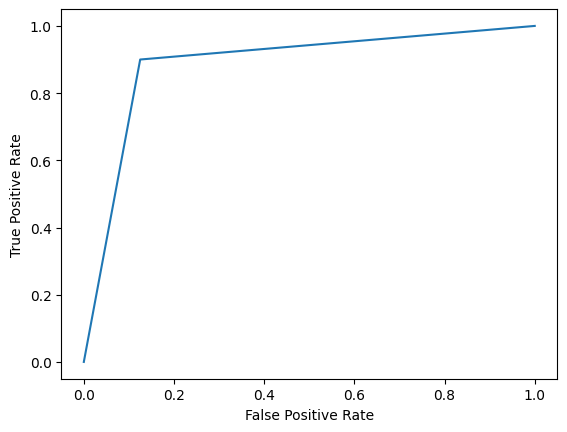

In [12]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

In [6]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba[:, 1]):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.889
Precision:1.000
Recall:  0.800
F1-score: 0.889
ROC-AUC:0.950

Confusion Matrix:
 [[8 0]
 [2 8]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      1.00      0.89         8
         1.0       1.00      0.80      0.89        10

    accuracy                           0.89        18
   macro avg       0.90      0.90      0.89        18
weighted avg       0.91      0.89      0.89        18



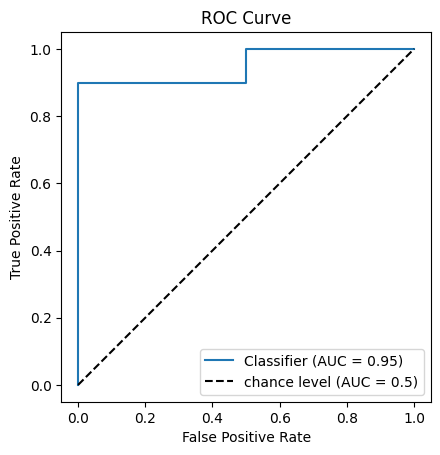

In [16]:
RocCurveDisplay.from_predictions(y_test, y_proba[:, 1])

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

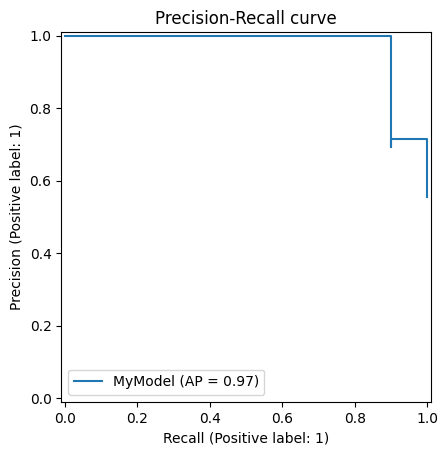

In [17]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba[:, 1], name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()